In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, mean_absolute_error
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

In [2]:
data = pd.read_csv("processed_data.csv")

In [3]:
forward_features = ['Study_Hours', 'Internal_Assessment_Score', 'Previous_Academic_Result']
backward_features = ['Study_Hours', 'Internal_Assessment_Score', 'Previous_Academic_Result']

In [4]:
#Regression Forward
X_f = data[forward_features]
y = data['Final_Grade']



X_train, X_test, y_train, y_test = train_test_split(X_f, y, test_size=0.2, random_state=42)

model_f = LinearRegression()
model_f.fit(X_train, y_train)

y_pred_f = model_f.predict(X_test)

r2_forward = r2_score(y_test, y_pred_f)
rmse_forward = np.sqrt(mean_squared_error(y_test, y_pred_f))
mae_forward = mean_absolute_error(y_test, y_pred_f)
mse_forward = mean_squared_error(y_test, y_pred_f)

print("Forward R2:", r2_forward)
print("Forward RMSE:", rmse_forward)
print("Forward MSE:", mse_forward)
print("Forward MAE:", mae_forward)

Forward R2: 0.6895301407018808
Forward RMSE: 10.268094348613122
Forward MSE: 105.43376155202074
Forward MAE: 7.275719463741165


In [5]:
#Regression Backward
X_b = data[backward_features]

X_train, X_test, y_train, y_test = train_test_split(X_b, y, test_size=0.2, random_state=42)

model_b = LinearRegression()
model_b.fit(X_train, y_train)

y_pred_b = model_b.predict(X_test)

r2_backward = r2_score(y_test, y_pred_b)
rmse_backward = np.sqrt(mean_squared_error(y_test, y_pred_b))
mae_backward = mean_absolute_error(y_test, y_pred_b)
mse_backward = mean_squared_error(y_test, y_pred_b)

print("Backward R2:", r2_backward)
print("Backward RMSE:", rmse_backward)
print("Backward MSE:", mse_backward)
print("Backward MAE:", mae_backward)

Backward R2: 0.6895301407018808
Backward RMSE: 10.268094348613122
Backward MSE: 105.43376155202074
Backward MAE: 7.275719463741165


In [6]:
print(" Feature Selection Comparison")

print("\nForward Selection:")
print("R2:", r2_forward)
print("RMSE:", rmse_forward)
print("MSE:", mse_forward)
print("MAE:", mae_forward)

print("\nBackward Selection:")
print("R2:", r2_backward)
print("RMSE:", rmse_backward)
print("MSE:", mse_backward)
print("MAE:", mae_backward)

 Feature Selection Comparison

Forward Selection:
R2: 0.6895301407018808
RMSE: 10.268094348613122
MSE: 105.43376155202074
MAE: 7.275719463741165

Backward Selection:
R2: 0.6895301407018808
RMSE: 10.268094348613122
MSE: 105.43376155202074
MAE: 7.275719463741165


In [7]:
print("--- Final Decision ---")

if (r2_forward > r2_backward) and (rmse_forward < rmse_backward):
    print("Forward Selection is better")
    best_features = forward_features

elif (r2_backward > r2_forward) and (rmse_backward < rmse_forward):
    print("Backward Selection is better")
    best_features = backward_features

elif abs(r2_forward - r2_backward) < 0.01:   # almost same performance
    print("Both Forward and Backward give similar performance")
    
    if rmse_forward < rmse_backward:
        print("selecting Forward")
        best_features = forward_features
    else:
        print("selecting Backward")
        best_features = backward_features

else:
    print("Mixed results:selecting Forward for simplicity") #Backward has better R² -Forward has better RMSE
    best_features = forward_features

print("Best Features:", best_features)

--- Final Decision ---
Both Forward and Backward give similar performance
selecting Backward
Best Features: ['Study_Hours', 'Internal_Assessment_Score', 'Previous_Academic_Result']


In [8]:
#Final Linear Regression Model
X = data[best_features]
y = data['Final_Grade']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

final_model = LinearRegression()
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

print("Final R2:", r2_score(y_test, y_pred))
print("Final RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Final MAE:", mean_absolute_error(y_test, y_pred))
print("Final MSE:",mean_squared_error(y_test, y_pred_f))

Final R2: 0.6895301407018808
Final RMSE: 10.268094348613122
Final MAE: 7.275719463741165
Final MSE: 105.43376155202074


In [9]:
# Regression using Decision Tree

X_dt = data[best_features]
y = data['Final_Grade']

X_train, X_test, y_train, y_test = train_test_split(X_dt, y, test_size=0.2, random_state=42)

model_dt = DecisionTreeRegressor(random_state=42)
model_dt.fit(X_train, y_train)

y_pred_dt = model_dt.predict(X_test)

r2_dt = r2_score(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)

print(" Decision Tree Regression ")
print("R2:", r2_dt)
print("RMSE:", rmse_dt)
print("MSE:", mse_dt)
print("MAE:", mae_dt)

 Decision Tree Regression 
R2: 0.7180275140132586
RMSE: 9.785510668245712
MSE: 95.75621903835062
MAE: 3.6408308823529416


In [10]:
# Regression using Random Forest

X_rf = data[best_features]
y = data['Final_Grade']

X_train, X_test, y_train, y_test = train_test_split(X_rf, y, test_size=0.2, random_state=42)

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)

print(" Random Forest Regression ")
print("R2:", r2_rf)
print("RMSE:", rmse_rf)
print("MSE:", mse_rf)
print("MAE:", mae_rf)

 Random Forest Regression 
R2: 0.8309515454736454
RMSE: 7.576798375274409
MSE: 57.407873619560924
MAE: 3.247565952390375


In [11]:
print(" Model Comparison ")
print("Linear R2:", r2_forward)
print("Decision Tree R2:", r2_dt)
print("Random Forest R2:", r2_rf)

 Model Comparison 
Linear R2: 0.6895301407018808
Decision Tree R2: 0.7180275140132586
Random Forest R2: 0.8309515454736454


In [12]:
# Classification
X = data[best_features]
y = data['Result']

# Train-Test Split with Stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply SMOTE for Imbalance Handling
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# Model Training (Logistic Regression)
c_model = LogisticRegression(max_iter=1000)
c_model.fit(X_train, y_train)

# Prediction
y_pred = c_model.predict(X_test)

# Evaluation
train_acc = c_model.score(X_train, y_train)
test_acc = c_model.score(X_test, y_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# Output
print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)
print("\nClassification Model")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:\n", cm)

Training Accuracy: 0.797866937531742
Testing Accuracy: 0.7895

Classification Model
Accuracy: 0.7895
Precision: 0.9210526315789473
Recall: 0.7819905213270142
F1 Score: 0.8458440131819847
Confusion Matrix:
 [[ 424   99]
 [ 322 1155]]


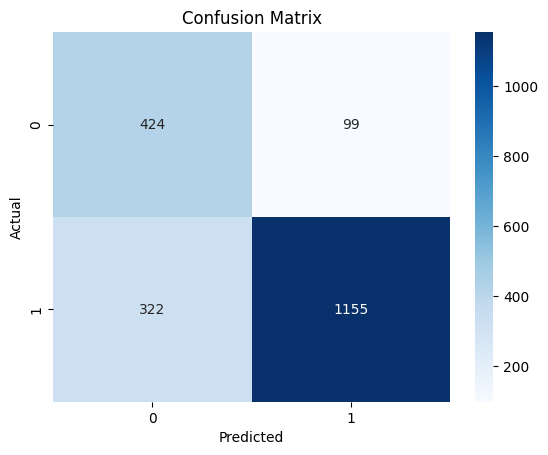

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [15]:
# Classification (SVM)

X = data[best_features]
y = data['Result']

# Train-Test Split (with stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 🔥 Imbalance handling (SMOTE)
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# SVM Model
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

# Prediction
y_pred_svm = svm_model.predict(X_test)

# Accuracy
train_acc_svm = svm_model.score(X_train, y_train)
test_acc_svm = svm_model.score(X_test, y_test)

print("SVM Classification")
print("Training Accuracy:", train_acc_svm)
print("Testing Accuracy:", test_acc_svm)

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm))

# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
print("Confusion Matrix:\n", cm_svm)

SVM Classification
Training Accuracy: 0.8153885220924327
Testing Accuracy: 0.8205
Accuracy: 0.8205
Precision: 0.9326625386996904
Recall: 0.8158429248476642
F1 Score: 0.8703503069700252
Confusion Matrix:
 [[ 436   87]
 [ 272 1205]]


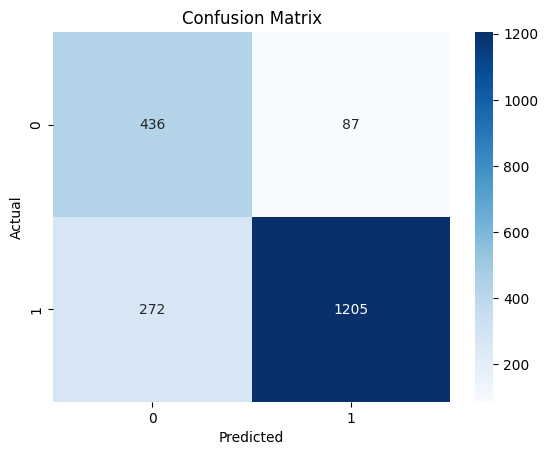

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [17]:
X = data[best_features]
y = data['Result']

# Split with stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 🔥 SMOTE (imbalance handling)
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Prediction
y_pred_rf = rf_model.predict(X_test)

# Accuracy
train_acc_rf = rf_model.score(X_train, y_train)
test_acc_rf = rf_model.score(X_test, y_test)

print("Random Forest Classification")
print("Training Accuracy:", train_acc_rf)
print("Testing Accuracy:", test_acc_rf)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:\n", cm_rf)

Random Forest Classification
Training Accuracy: 0.9928897917724734
Testing Accuracy: 0.949
Accuracy: 0.949
Precision: 0.96673455532926
Recall: 0.964116452268111
F1 Score: 0.9654237288135593
Confusion Matrix:
 [[ 474   49]
 [  53 1424]]


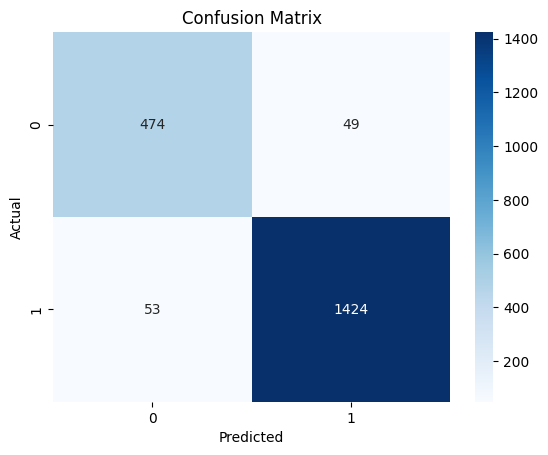

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [19]:
print("Logistic Regression")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

print("\nSVM")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1:", f1_score(y_test, y_pred_svm))

print("\nRandom Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))

Logistic Regression
Accuracy: 0.7895
Precision: 0.9210526315789473
Recall: 0.7819905213270142
F1: 0.8458440131819847

SVM
Accuracy: 0.8205
Precision: 0.9326625386996904
Recall: 0.8158429248476642
F1: 0.8703503069700252

Random Forest
Accuracy: 0.949
Precision: 0.96673455532926
Recall: 0.964116452268111
F1: 0.9654237288135593


In [20]:
# MODEL TRAINING BY USING PCA
X_pca_df = pd.read_csv("pca_data.csv")

In [21]:
# PCA Linear Regression

X = X_pca_df
y = data['Final_Grade']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(" PCA Linear Regression ")
print("R2:", r2)
print("RMSE:", rmse)
print("MSE:", mse)
print("MAE:", mae)

 PCA Linear Regression 
R2: 0.6901665638723045
RMSE: 10.257564815226704
MSE: 105.21763593857686
MAE: 7.335080331165885


In [22]:
# PCA Decision Tree Regression

X = X_pca_df
y = data['Final_Grade']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2_dt = r2_score(y_test, y_pred)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred))
mse_dt = mean_squared_error(y_test, y_pred)
mae_dt = mean_absolute_error(y_test, y_pred)

print(" PCA Decision Tree ")
print("R2:", r2_dt)
print("RMSE:", rmse_dt)
print("MSE:", mse_dt)
print("MAE:", mae_dt)

 PCA Decision Tree 
R2: 0.39008085588035757
RMSE: 14.391837964624255
MSE: 207.125
MAE: 8.425


In [23]:
# PCA Random Forest Regression

X = X_pca_df
y = data['Final_Grade']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2_rf = r2_score(y_test, y_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred))
mse_rf = mean_squared_error(y_test, y_pred)
mae_rf = mean_absolute_error(y_test, y_pred)

print(" PCA Random Forest ")
print("R2:", r2_rf)
print("RMSE:", rmse_rf)
print("MSE:", mse_rf)
print("MAE:", mae_rf)

 PCA Random Forest 
R2: 0.6768368776034175
RMSE: 10.475892324761649
MSE: 109.74432
MAE: 7.3657


In [24]:
# ================== PCA Logistic Regression (with imbalance) ==================

X = X_pca_df
y = data['Result']

# Train-Test Split with stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 🔥 SMOTE (imbalance handling)
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Prediction
y_pred_log = model.predict(X_test)

# Output
print("PCA Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))

cm_log_pca = confusion_matrix(y_test, y_pred_log)
print("Confusion Matrix:\n", cm_log_pca)

PCA Logistic Regression
Accuracy: 0.7945
Precision: 0.9257188498402555
Recall: 0.7846987136086662
F1 Score: 0.8493953829241481
Confusion Matrix:
 [[ 430   93]
 [ 318 1159]]


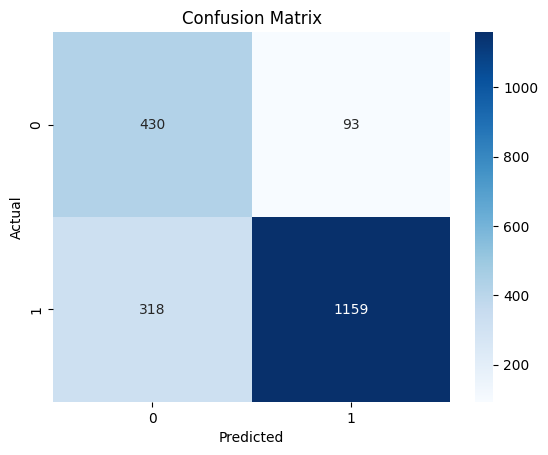

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm_log_pca, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [26]:
# PCA SVM Classification

X = X_pca_df
y = data['Result']

# Split (with stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 🔥 SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# Model
model = SVC(kernel='linear')
model.fit(X_train, y_train)

# Prediction
y_pred_svm = model.predict(X_test)

print("PCA SVM")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm))

cm_svm_pca = confusion_matrix(y_test, y_pred_svm)
print("Confusion Matrix:\n", cm_svm_pca)

PCA SVM
Accuracy: 0.8175
Precision: 0.9244274809160306
Recall: 0.8199052132701422
F1 Score: 0.8690348044492285
Confusion Matrix:
 [[ 424   99]
 [ 266 1211]]


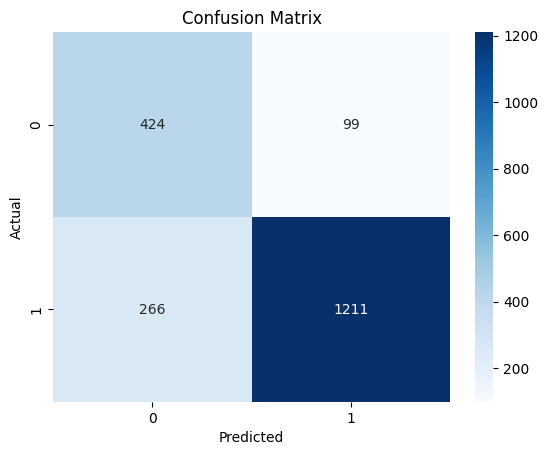

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm_svm_pca, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [28]:
# PCA Random Forest Classification

X = X_pca_df
y = data['Result']

# Split (with stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 🔥 SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred_rf = model.predict(X_test)

print("PCA Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

cm_rf_pca = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:\n", cm_rf_pca)

PCA Random Forest
Accuracy: 0.873
Precision: 0.9117845117845118
Recall: 0.916723087339201
F1 Score: 0.9142471303173532
Confusion Matrix:
 [[ 392  131]
 [ 123 1354]]


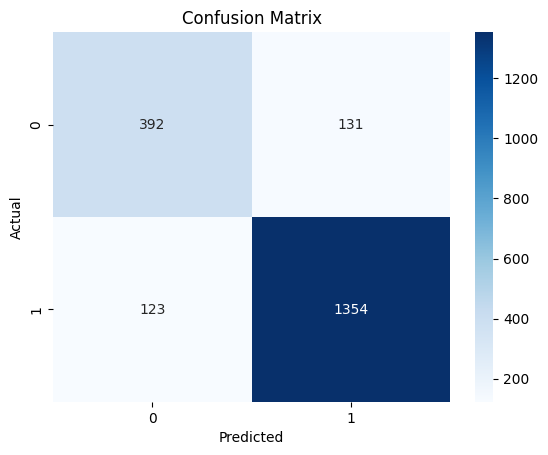

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm_rf_pca, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [30]:
print(" PCA Regression Model Comparison ")

print("PCA Linear R2:", r2)
print("PCA Decision Tree R2:", r2_dt)
print("PCA Random Forest R2:", r2_rf)

print("\nPCA Linear RMSE:", rmse)
print("PCA Decision Tree RMSE:", rmse_dt)
print("PCA Random Forest RMSE:", rmse_rf)

print("\nPCA Linear MSE:", mse)
print("PCA Decision Tree MSE:", mse_dt)
print("PCA Random Forest MSE:", mse_rf)

print("\nPCA Linear MAE:", mae)
print("PCA Decision Tree MAE:", mae_dt)
print("PCA Random Forest MAE:", mae_rf)

 PCA Regression Model Comparison 
PCA Linear R2: 0.6901665638723045
PCA Decision Tree R2: 0.39008085588035757
PCA Random Forest R2: 0.6768368776034175

PCA Linear RMSE: 10.257564815226704
PCA Decision Tree RMSE: 14.391837964624255
PCA Random Forest RMSE: 10.475892324761649

PCA Linear MSE: 105.21763593857686
PCA Decision Tree MSE: 207.125
PCA Random Forest MSE: 109.74432

PCA Linear MAE: 7.335080331165885
PCA Decision Tree MAE: 8.425
PCA Random Forest MAE: 7.3657


In [31]:
print(" PCA Classification Model Comparison ")

print("PCA Logistic Accuracy:", accuracy_score(y_test, y_pred_log))
print("PCA SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("PCA Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nPCA Logistic Precision:", precision_score(y_test, y_pred_log))
print("PCA SVM Precision:", precision_score(y_test, y_pred_svm))
print("PCA Random Forest Precision:", precision_score(y_test, y_pred_rf))

print("\nPCA Logistic Recall:", recall_score(y_test, y_pred_log))
print("PCA SVM Recall:", recall_score(y_test, y_pred_svm))
print("PCA Random Forest Recall:", recall_score(y_test, y_pred_rf))

print("\nPCA Logistic F1:", f1_score(y_test, y_pred_log))
print("PCA SVM F1:", f1_score(y_test, y_pred_svm))
print("PCA Random Forest F1:", f1_score(y_test, y_pred_rf))

 PCA Classification Model Comparison 
PCA Logistic Accuracy: 0.7945
PCA SVM Accuracy: 0.8175
PCA Random Forest Accuracy: 0.873

PCA Logistic Precision: 0.9257188498402555
PCA SVM Precision: 0.9244274809160306
PCA Random Forest Precision: 0.9117845117845118

PCA Logistic Recall: 0.7846987136086662
PCA SVM Recall: 0.8199052132701422
PCA Random Forest Recall: 0.916723087339201

PCA Logistic F1: 0.8493953829241481
PCA SVM F1: 0.8690348044492285
PCA Random Forest F1: 0.9142471303173532


In [32]:
import pandas as pd
import joblib
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# ---------------- LOAD DATA ----------------
data = pd.read_csv("processed_data.csv")

# ---------------- FEATURES ----------------
best_features = [
    'Study_Hours',
    'Attendance_Percentage',
    'Internal_Assessment_Score',
    'Previous_Academic_Result',
    'Internet_Usage_Hours'
]

# ---------------- INPUT & TARGETS ----------------
X = data[best_features]
y_reg = data['Final_Grade']
y_clf = data['Result']

# ---------------- MODELS ----------------

# 🎯 Regression (BEST MODEL YOU SELECTED)
score_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
score_model.fit(X, y_reg)

# 🎯 Classification (YOUR MODEL)
result_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
result_model.fit(X, y_clf)

# ---------------- SAVE ----------------
joblib.dump(score_model, "score_model.pkl")
joblib.dump(result_model, "result_model.pkl")

print("✅ Correct models saved successfully")

✅ Correct models saved successfully


In [ ]:
import joblib
import numpy as np

# ---------------- LOAD MODELS ----------------

score_model = joblib.load("score_model.pkl")
result_model = joblib.load("result_model.pkl")

# ---------------- USER INPUT ----------------

study_hours = float(input("Enter Study Hours: "))
attendance = float(input("Enter Attendance (%): "))
internal_score = float(input("Enter Internal Score (out of 40): "))
previous_result = float(input("Enter Previous Result (out of 100): "))
internet_usage = float(input("Enter Internet Usage Hours: "))

# ---------------- CREATE INPUT ARRAY ----------------

input_data = np.array([[ 
    study_hours,
    attendance,
    internal_score,
    previous_result,
    internet_usage
]])

# ---------------- PREDICTIONS ----------------

predicted_score = score_model.predict(input_data)[0]
predicted_class = result_model.predict(input_data)[0]

# ---------------- RESULT ----------------

if predicted_class in [1, "Pass", "PASS"]:
    result_text = "PASS"
else:
    result_text = "FAIL"

predicted_score = max(0, min(100, predicted_score))

# ---------------- OUTPUT ----------------

print("\n RESULTS")
print(" Predicted Score:", round(predicted_score, 2), "/100")
print(" Model Prediction:", result_text)